# Healthcare: Medical Insurance Cost Prediction

# Exploratory Data Analysis (EDA) and Visualization

## Objectives
-	Understand data distribution
-	Identify relationships between variables
-	Detect outliers
-	Discover key drivers of insurance charges

## 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

#scikit-learn library
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## 2. import Dataset

In [ ]:
#from google.colab import files
#uploaded = files.upload()

import pandas as pd

df = pd.read_csv("insurance.csv")

df.head()

Saving insurance.csv to insurance (1).csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df = pd.read_csv("insurance.csv")

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
#remove duplicate records if any exist

df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

## 3. Understand the Dataset

| Variable | Description                              |
| -------- | ---------------------------------------- |
| age      | Age of beneficiary                       |
| sex      | Male/Female                              |
| bmi      | Body Mass Index                          |
| children | Number of dependents                     |
| smoker   | Smoking status                           |
| region   | Residential region                       |
| charges  | Medical insurance cost (Target Variable) |


## 4. Data Quality Checks

checking for null values

In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_cols

['age', 'bmi', 'children', 'charges']

# 3. Age Analysis Visualization

### Objective
To understand how age influences medical insurance charges.

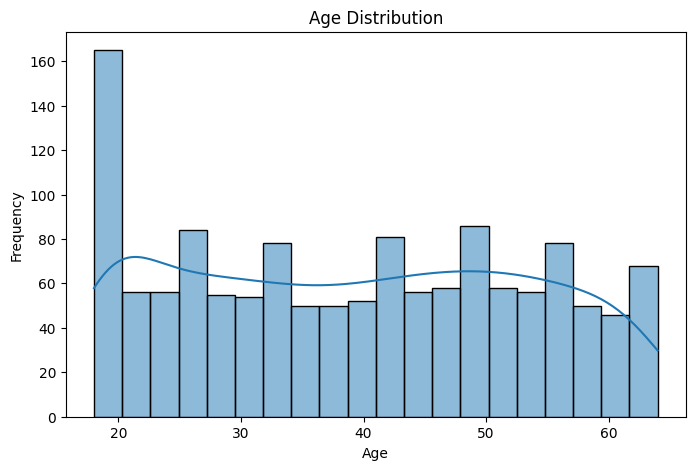

In [ ]:
#Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## The population is fairly distributed across different age groups with a slight concentration among younger adults.

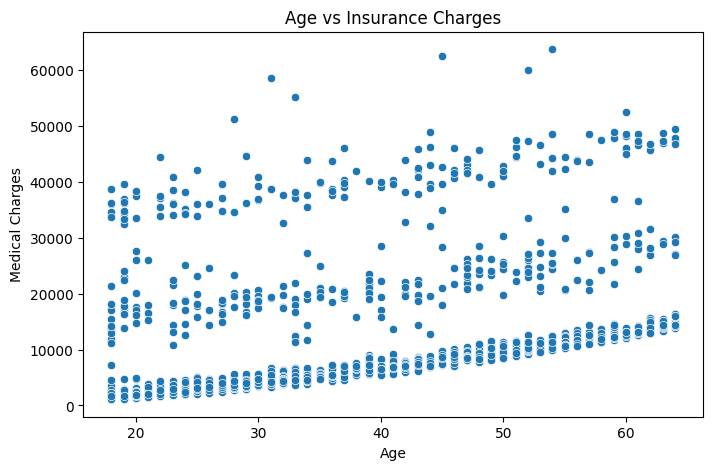

In [ ]:
#Age vs Insurance Charges

plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.show()

### Interpretation
-	The dataset contains individuals between ages 18 and 64.
-	Most policyholders are concentrated between 20 and 50 years.
-	Medical insurance charges generally increase with age.
-	Older individuals tend to incur higher healthcare costs than younger individuals.

### Key Finding
Age has a positive relationship with insurance charges, indicating that healthcare expenses increase as people grow older.


## 4. BMI Analysis Visualization

### Objective
To determine the effect of Body Mass Index (BMI) on insurance charges.


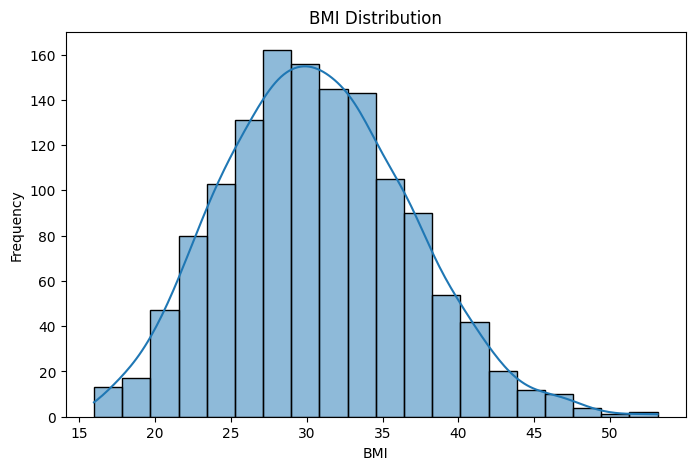

In [ ]:
#BMI Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

Most policyholders have BMI levels indicating overweight conditions.

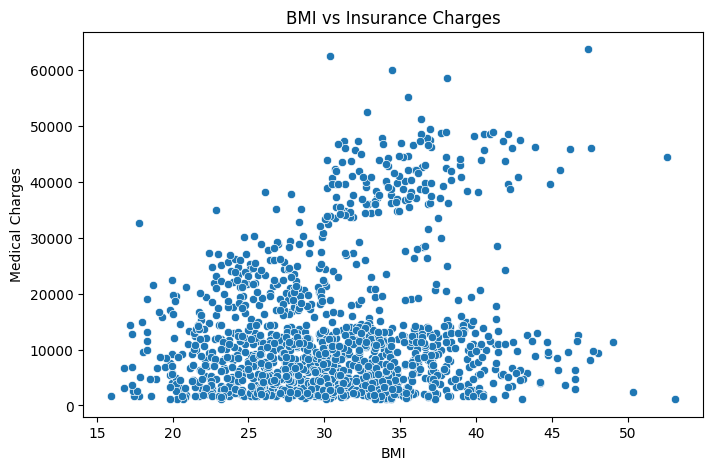

In [ ]:
#BMI vs Charges

plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.show()

### Interpretation
-	BMI values are approximately normally distributed.
-	Most individuals have BMI values between 25 and 35.
-	Insurance charges tend to increase as BMI increases.
-	Individuals with BMI above 30 generally have higher medical expenses.

### Key Finding
BMI shows a positive correlation with insurance charges, suggesting that obesity-related health risks contribute to increased healthcare costs.


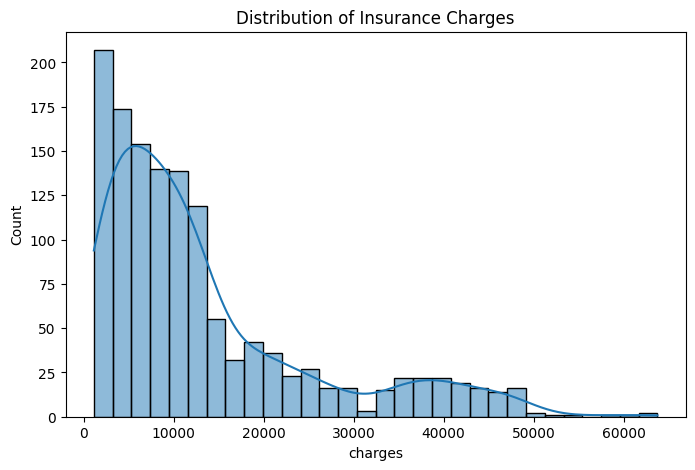

In [ ]:
#Charges Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

The target variable is right-skewed, indicating a few individuals incur extremely high medical costs


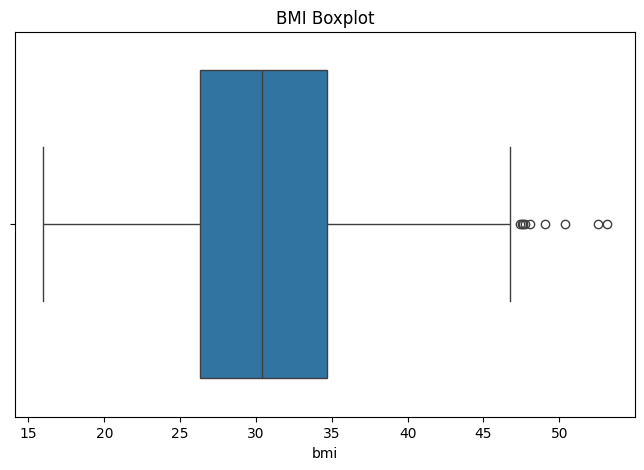

In [ ]:
#Boxplot of BMI

plt.figure(figsize=(8,5))
sns.boxplot(x=df['bmi'])
plt.title('BMI Boxplot')
plt.show()

A few BMI outliers exist, representing individuals with exceptionally high body mass index values.

## 5. EDA Insights

### Summary of Findings
### Age
-	Age is positively correlated with medical insurance charges.
-	Older individuals generally pay higher insurance costs.
-	Healthcare expenses increase progressively with age.
### BMI
-	BMI is positively associated with insurance charges.
-	Individuals with higher BMI values tend to incur larger medical expenses.
-	Obesity appears to be an important factor affecting healthcare costs.
### Distribution of Charges
-	Insurance charges are highly skewed.
-	A small number of policyholders generate very high medical costs.
### Business Implications
i.	 Age significantly influences healthcare expenditure and should be retained as a key predictive feature.

ii.	 BMI contributes meaningfully to medical costs and should be included in predictive models.

iii. Insurance providers can use age and BMI information to better estimate future healthcare expenses.

iv.	 Preventive health programs targeting obesity may help reduce long-term medical costs.

In [ ]:
df['sex'].value_counts()

,count
sex,
male,675
female,662


In [ ]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [ ]:
df['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [ ]:
df.groupby('sex')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
female,662.0,12569.578844,11128.703801,1607.5101,4885.158700,9412.9625,14454.691825,63770.42801
male,675.0,13974.998864,12971.958663,1121.8739,4654.022675,9377.9047,19006.685500,62592.87309


In [ ]:
df.groupby("smoker")["charges"].describe()

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,1063.0,8440.660307,5992.973800,1121.8739,3988.883500,7345.72660,11363.019100,36910.60803
yes,274.0,32050.231832,11541.547176,12829.4551,20826.244213,34456.34845,41019.207275,63770.42801


In [ ]:
df.groupby('region')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,324.0,13406.384516,11255.803066,1694.7964,5194.322288,10057.652025,16687.364100,58571.07448
northwest,324.0,12450.840844,11073.125699,1621.3402,4733.635288,8976.977250,14788.747863,60021.39897
southeast,364.0,14735.411438,13971.098589,1121.8739,4440.886200,9294.131950,19526.286900,63770.42801
southwest,325.0,12346.937377,11557.179101,1241.5650,4751.070000,8798.593000,13462.520000,52590.82939


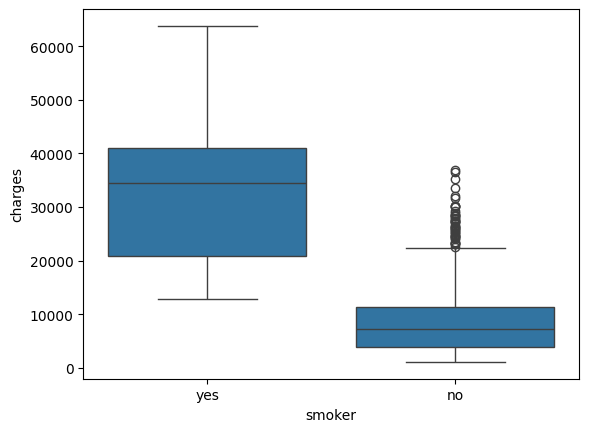

In [ ]:
sns.boxplot(data= df, x = "smoker", y = "charges")
plt.show()

In [ ]:
df.groupby(['sex', 'smoker'])['charges'].describe()

count          mean           std         min           25%  \
sex    smoker                                                                
female no      547.0   8762.297300   6060.775970   1607.5101   4265.599100   
       yes     115.0  30678.996276  11907.536381  13844.5060  19696.432100   
male   no      516.0   8099.700161   5907.000174   1121.8739   3684.907500   
       yes     159.0  33042.005975  11202.670862  12829.4551  21241.526875   

                        50%          75%          max  
sex    smoker                                          
female no       7639.417450  11786.16660  36910.60803  
       yes     28950.469200  40918.31450  63770.42801  
male   no       6986.101975  10960.85900  32108.66282  
       yes     36085.219000  41797.58905  62592.87309

In [ ]:
df.groupby(['region', 'smoker'])['charges'].describe()

count          mean           std         min           25%  \
region    smoker                                                                
northeast no      257.0   9165.531672   6157.196439   1694.7964   4438.263400   
          yes      67.0  29673.536473  11589.559770  12829.4551  19881.400425   
northwest no      266.0   8582.467101   6125.331366   1621.3402   4201.807987   
          yes      58.0  30192.003182  11413.827702  14711.7438  20834.130337   
southeast no      273.0   8032.216309   6137.329758   1121.8739   3471.409600   
          yes      91.0  34844.996824  11324.766536  16577.7795  23155.105450   
southwest no      267.0   8019.284513   5489.514421   1241.5650   3947.026500   
          yes      58.0  32269.063494  11270.279593  13844.5060  20396.042022   

                           50%           75%          max  
region    smoker                                           
northeast no       8342.908750  11938.255950  32108.66282  
          yes     28101.333050  39576.950850  58571.07448  
northwest no       7259.232050  11355.802575  33471.97189  
          yes     27488.996475  39918.948975  60021.39897  
southeast no       6652.528800  10982.501300  36580.28216  
          yes     37484.449300  43391.859400  63770.42801  
southwest no       7348.142000  11017.990500  36910.60803  
          yes     35165.256500  39809.292750  52590.82939

## Feature Engineering, Feature Encoding

#### Label Encoder

In [ ]:
le = LabelEncoder() #create an instance
df["sex"] = le.fit_transform(df["sex"]) #transform each categorical column
df["smoker"] = le.fit_transform(df["smoker"])

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


### One Hot Encoder

In [ ]:
df_encoded = df.copy()

In [ ]:
df_encoded = pd.get_dummies(df, columns=["region"], dtype=int)

In [ ]:
df_encoded.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='object')

In [ ]:
df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [ ]:
df_encoded.dtypes

,0
age,int64
sex,int64
bmi,float64
children,int64
smoker,int64
charges,float64
region_northeast,int64
region_northwest,int64
region_southeast,int64
region_southwest,int64


### Train-test Split

In [ ]:
#X is the independent variable - features
#y is the dependent variable - target

x = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

In [ ]:
#80:20 ratio
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape

(1069, 9)

In [ ]:
x_test.shape

(268, 9)

In [ ]:
x_train.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
1114,23,1,24.510,0,0,1,0,0,0
968,21,1,25.745,2,0,1,0,0,0
599,52,0,37.525,2,0,0,1,0,0
170,63,1,41.470,0,0,0,0,1,0
275,47,0,26.600,2,0,1,0,0,0


In [ ]:
x_train.dtypes

,0
age,int64
sex,int64
bmi,float64
children,int64
smoker,int64
region_northeast,int64
region_northwest,int64
region_southeast,int64
region_southwest,int64


### Feature Scaling

In [ ]:
#Standard Scaler (Mean=0, std=1)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
x_train_scaled

array([[-1.1576804 ,  0.97140947, -0.99692768, ..., -0.57266946,
        -0.60581158, -0.57410974],
       [-1.30061876,  0.97140947, -0.79276204, ..., -0.57266946,
        -0.60581158, -0.57410974],
       [ 0.91492586, -1.029432  ,  1.15466402, ...,  1.74620801,
        -0.60581158, -0.57410974],
       ...,
       [-1.37208794,  0.97140947, -1.4118716 , ..., -0.57266946,
        -0.60581158,  1.74182728],
       [-0.08564268, -1.029432  , -0.41997378, ..., -0.57266946,
        -0.60581158,  1.74182728],
       [-0.30005022, -1.029432  ,  0.87941237, ..., -0.57266946,
         1.65067825, -0.57410974]])

In [ ]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_train_scaled

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.157680,0.971409,-0.996928,-0.907908,-0.500292,1.795911,-0.572669,-0.605812,-0.574110
1,-1.300619,0.971409,-0.792762,0.766904,-0.500292,1.795911,-0.572669,-0.605812,-0.574110
2,0.914926,-1.029432,1.154664,0.766904,-0.500292,-0.556820,1.746208,-0.605812,-0.574110
3,1.701087,0.971409,1.806837,-0.907908,-0.500292,-0.556820,-0.572669,1.650678,-0.574110
4,0.557580,-1.029432,-0.651417,0.766904,-0.500292,1.795911,-0.572669,-0.605812,-0.574110
...,...,...,...,...,...,...,...,...,...
1064,0.843457,-1.029432,0.730628,0.766904,1.998831,1.795911,-0.572669,-0.605812,-0.574110
1065,-0.871804,0.971409,2.539188,0.766904,-0.500292,-0.556820,-0.572669,-0.605812,1.741827
1066,-1.372088,0.971409,-1.411872,-0.070502,-0.500292,-0.556820,-0.572669,-0.605812,1.741827
1067,-0.085643,-1.029432,-0.419974,1.604310,-0.500292,-0.556820,-0.572669,-0.605812,1.741827


In [ ]:
x_test_scaled

array([[ 0.70051832,  0.97140947, -1.3267337 , ..., -0.57266946,
        -0.60581158, -0.57410974],
       [-0.72886531, -1.029432  , -0.8167329 , ..., -0.57266946,
        -0.60581158,  1.74182728],
       [ 0.84345668, -1.029432  ,  0.96620343, ...,  1.74620801,
        -0.60581158, -0.57410974],
       ...,
       [-1.22914958, -1.029432  ,  0.6678075 , ..., -0.57266946,
        -0.60581158, -0.57410974],
       [ 1.5581485 ,  0.97140947,  0.95215155, ..., -0.57266946,
        -0.60581158,  1.74182728],
       [ 0.55757996, -1.029432  , -1.02833777, ..., -0.57266946,
        -0.60581158, -0.57410974]])

In [ ]:
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)
x_test_scaled

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,0.700518,0.971409,-1.326734,-0.907908,-0.500292,1.795911,-0.572669,-0.605812,-0.574110
1,-0.728865,-1.029432,-0.816733,2.441716,-0.500292,-0.556820,-0.572669,-0.605812,1.741827
2,0.843457,-1.029432,0.966203,1.604310,-0.500292,-0.556820,1.746208,-0.605812,-0.574110
3,-0.585927,0.971409,0.636397,1.604310,1.998831,-0.556820,1.746208,-0.605812,-0.574110
4,-0.585927,0.971409,1.297663,0.766904,-0.500292,-0.556820,-0.572669,1.650678,-0.574110
...,...,...,...,...,...,...,...,...,...
263,1.772556,0.971409,1.643174,-0.907908,-0.500292,-0.556820,-0.572669,1.650678,-0.574110
264,1.701087,-1.029432,0.952152,-0.907908,-0.500292,-0.556820,-0.572669,1.650678,-0.574110
265,-1.229150,-1.029432,0.667808,0.766904,-0.500292,1.795911,-0.572669,-0.605812,-0.574110
266,1.558148,0.971409,0.952152,-0.070502,1.998831,-0.556820,-0.572669,-0.605812,1.741827


This Feature engineering aspect focuses on preparing the data for machine learning.

 The categorical variables were converted into numerical values through encoding, while the numerical features were scaled where necessary to ensure they were on a similar range.

 These steps helped the model understand the data more effectively, resulting in more accurate predictions of insurance costs.

## Geoffrey's Section
Decision Tree, Random Forest, Gradient Boosting, and Feature Importance Analysis

Decision Tree


,Feature,Importance
4,smoker,0.599279
2,bmi,0.215213
0,age,0.130548
5,region,0.026081
3,children,0.020006
1,sex,0.008873


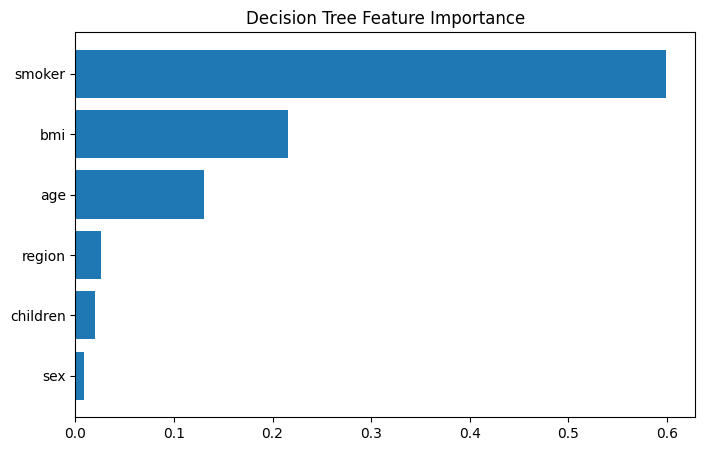

Random Forest


,Feature,Importance
4,smoker,0.599299
2,bmi,0.216442
0,age,0.137458
3,children,0.023413
5,region,0.016152
1,sex,0.007236


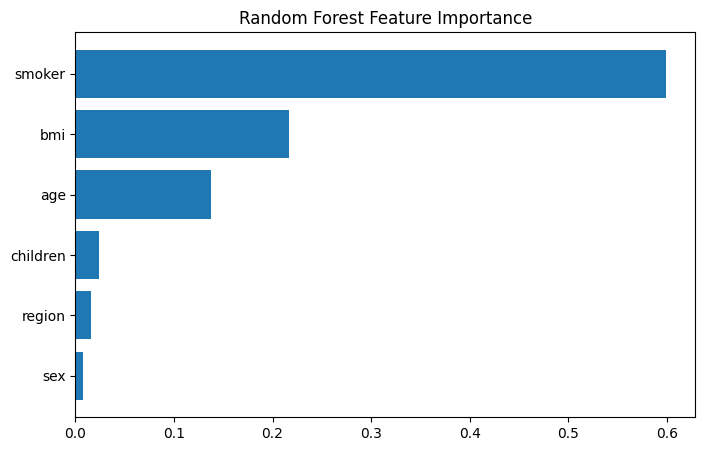

Gradient Boosting


,Feature,Importance
4,smoker,0.670914
2,bmi,0.188441
0,age,0.122871
3,children,0.012764
5,region,0.003860
1,sex,0.001150


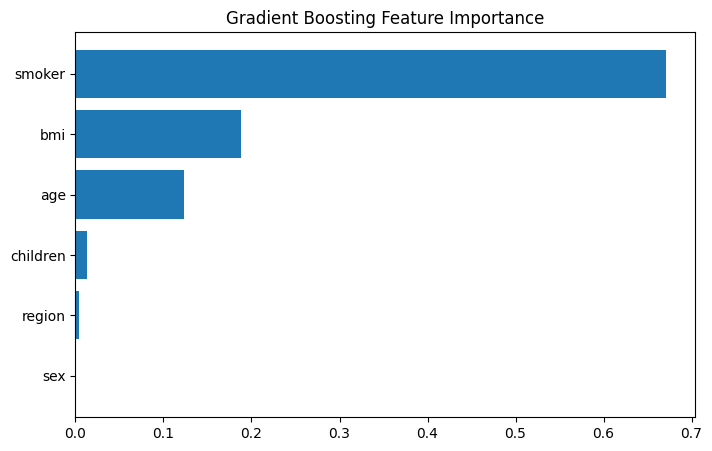

Geoffrey section completed.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt
import pandas as pd

data=df.copy()
enc=LabelEncoder()
for c in data.select_dtypes(include='object').columns:
    data[c]=enc.fit_transform(data[c])
X=data.drop('charges',axis=1)
y=data['charges']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
models={
'Decision Tree':DecisionTreeRegressor(random_state=42),
'Random Forest':RandomForestRegressor(n_estimators=200,random_state=42),
'Gradient Boosting':GradientBoostingRegressor(random_state=42)
}
for name,model in models.items():
    model.fit(X_train,y_train)
    fi=pd.DataFrame({'Feature':X.columns,'Importance':model.feature_importances_}).sort_values('Importance',ascending=False)
    print(name)
    display(fi)
    plt.figure(figsize=(8,5))
    plt.barh(fi['Feature'],fi['Importance'])
    plt.gca().invert_yaxis()
    plt.title(f'{name} Feature Importance')
    plt.show()
print('Geoffrey section completed.')

## Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='R2', ascending=False))

,Model,MAE,MSE,RMSE,R2
2,Gradient Boosting,2508.418118,1.817026e+07,4262.658690,0.901117
1,Random Forest,2546.224653,2.139568e+07,4625.546730,0.883565
0,Decision Tree,2948.178904,4.018429e+07,6339.107593,0.781317


### Model Performance Report: Medical Insurance Cost Prediction

This report evaluates three machine learning models:
* Decision Tree,
* Random Forest
* Gradient Boosting

They are trained to predict medical insurance charges. The models were assessed using key regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²).

Performance Summary:

| Model              | MAE     | MSE      | RMSE    | R²    |
|--------------------|--------:|---------:|--------:|-------:|
| Gradient Boosting  | 2508.42 | 1.82e+07 | 4262.66 | 0.901 |
| Random Forest      | 2546.22 | 2.14e+07 | 4625.55 | 0.884 |
| Decision Tree      | 2948.18 | 4.02e+07 | 6339.11 | 0.781 |

**Interpretation of Metrics**:

1. R² (R-squared): Represents the proportion of variance in the dependent variable that can be predicted from the independent variables. A higher R² indicates a better fit.

2. MAE (Mean Absolute Error): The average of the absolute differences between predictions and actual observations. It measures the average magnitude of the errors in a set of predictions, without considering their direction.

3. MSE (Mean Squared Error): The average of the squares of the errors. It gives a higher weight to larger errors.

4. RMSE (Root Mean Squared Error): The square root of the MSE.

**Conclusion and Best Model Selection**:

Based on the evaluation metrics, the Gradient Boosting model demonstrates superior performance across all evaluated metrics:

1. It achieved the highest R² score of 0.901, meaning it explains approximately 90.1% of the variance in medical charges, indicating a strong predictive capability.

2. It also recorded the lowest MAE (2508.42), MSE (1.82e+07), and RMSE (4262.66), suggesting that its predictions are, on average, closer to the actual medical charges compared to the other models.

While Random Forest also performed well with a competitive R² of 0.884, Gradient Boosting slightly edges it out. The Decision Tree model showed the lowest performance, indicating it might not be capturing the underlying relationships in the data as effectively as the ensemble methods.

Therefore, the Gradient Boosting model is selected as the best performing model for predicting medical insurance costs in this analysis due to its highest R² score and lowest error metrics.

## Save Best Model

In [ ]:
import joblib

best_model = models['Gradient Boosting']

# Saving the model to a file
joblib.dump(best_model, 'gradient_boosting_model.joblib')

['gradient_boosting_model.joblib']